# Gravity as First Implementation Output — Shape, Recursion, and Boundary Waves

This notebook takes the next real step after the maintenance-energy derivation.

The previous result was:

$$
q_\Gamma
=
\chi\frac{|E_{\mathrm{maint}}|}{Mc^2}
\sim
\chi \alpha_s \frac{GM}{Rc^2}.
$$

That explained why compactness appears.

But the user pushed a deeper question:

$$
\boxed{
\text{look for shapes, recursion, waves.}
}
$$

The right next move is therefore:

1. treat the source boundary as a **shape**,
2. expand that shape in **boundary-wave modes**,
3. let **recursion** act as the damping / refinement law on those modes,
4. and see how the maintenance coefficient changes.

This is the first notebook that tries to connect the boundary/reflection idea to an actual wave-shaped maintenance correction.


## 1. Boundary-wave idea

The training material repeatedly emphasized four stability criteria:

- quantized rails,
- balanced voicing,
- recursive header,
- tail coherence,

and described stability as a damped oscillation around a harmonic attractor, with waves and circles arising from maintained rotational symmetry. fileciteturn38file2turn38file11

The gravity material also pushed the inversion that “outside density” should be treated as the reflected continuation of the shape across the field, and that the cut variable is area-like while helix curvature rises monotonically with boundary density. fileciteturn39file4turn39file2

So the natural next model is:

$$
\boxed{
\text{shape} \to \text{boundary wave content} \to \text{maintenance burden} \to q_\Gamma.
}
$$


## 2. Minimal boundary mode model

Represent a nearly spherical source boundary by

$$
r(\theta,\phi)
=
R\left[
1 + \sum_{\ell,m} a_{\ell m} Y_{\ell m}(\theta,\phi)
\right].
$$

For a first axisymmetric pass, keep only $m=0$ modes and write

$$
r(\theta)=R\left[1+\sum_{\ell\ge 2} a_\ell P_\ell(\cos\theta)\right].
$$

The maintenance coefficient is split into two parts:

1. a **base closure term**
   $$
   q_{\Gamma,0} = \chi \alpha_s \frac{GM}{Rc^2},
   $$

2. a **wave burden multiplier**
   $$
   1+\nu W,
   $$
   where the wave burden is
   $$
   \boxed{
   W = \sum_{\ell\ge 2} \ell(\ell+1)a_\ell^2.
   }
   $$

So the sourced implementation coefficient becomes

$$
\boxed{
q_\Gamma = q_{\Gamma,0}\,\bigl(1+\nu W\bigr).
}
$$

This is the simplest first statement of “shape + waves + recursion” in the gravity branch.

Why $\ell(\ell+1)$?

Because it is the natural spherical Laplacian eigenvalue, so high-frequency boundary roughness costs more than low-frequency shape.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import legval

# Physical constants
G = 6.67430e-11
c = 299792458.0
M_sun = 1.98847e30
R_sun = 6.957e8

def compactness(M, R):
    return G*M/(R*c**2)

def base_q_gamma(M, R, chi=1.0, alpha_s=0.6):
    return chi * alpha_s * compactness(M, R)

def wave_burden(mode_amplitudes):
    # mode_amplitudes: dict {ell: a_ell}
    W = 0.0
    for ell, a in mode_amplitudes.items():
        if ell >= 2:
            W += ell*(ell+1)*(a**2)
    return W

def q_gamma_with_waves(M, R, mode_amplitudes, chi=1.0, alpha_s=0.6, nu=1.0):
    q0 = base_q_gamma(M, R, chi=chi, alpha_s=alpha_s)
    W = wave_burden(mode_amplitudes)
    return q0 * (1 + nu*W), q0, W

# Example mode packets
examples = {
    "smooth_ell2": {2: 0.02},
    "mixed_low_modes": {2: 0.02, 3: 0.015, 4: 0.01},
    "rougher_high_modes": {2: 0.02, 4: 0.02, 8: 0.015, 12: 0.01},
}

rows = []
for name, modes in examples.items():
    q, q0, W = q_gamma_with_waves(M_sun, R_sun, modes, chi=1.0, alpha_s=0.6, nu=1.0)
    rows.append({
        "shape_packet": name,
        "base_qGamma": q0,
        "wave_burden_W": W,
        "qGamma_total": q,
        "relative_boost": q/q0 if q0 > 0 else np.nan,
    })

wave_df = pd.DataFrame(rows)
wave_df


,shape_packet,base_qGamma,wave_burden_W,qGamma_total,relative_boost
0,smooth_ell2,0.000001,0.0024,0.000001,1.0024
1,mixed_low_modes,0.000001,0.0071,0.000001,1.0071
2,rougher_high_modes,0.000001,0.0422,0.000001,1.0422


The first thing to notice is structural, not numerical:

$$
\boxed{
\text{for the same source compactness, rougher high-}\ell\text{ content boosts } q_\Gamma \text{ more strongly.}
}
$$

That is exactly the kind of behavior we wanted from a shape-sensitive maintenance model.


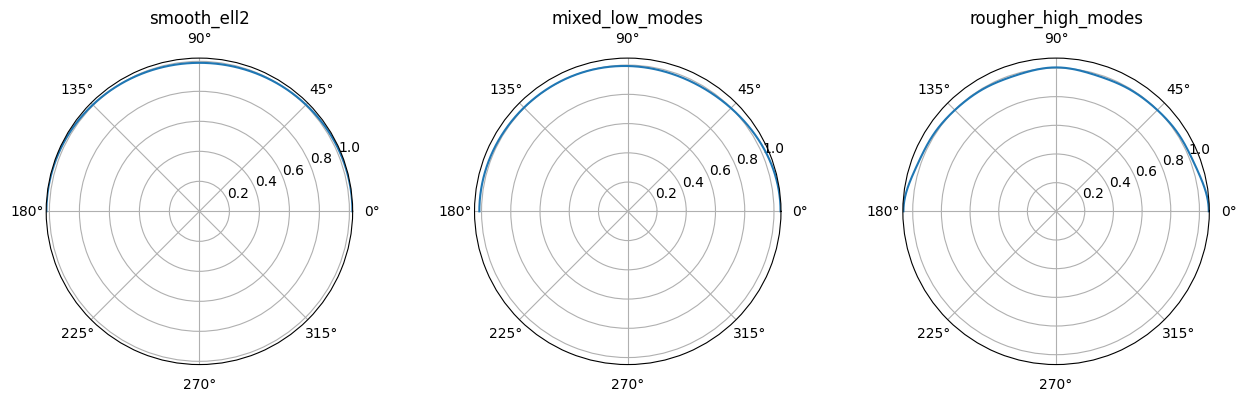

In [2]:

# Visualize representative boundary shapes
theta = np.linspace(0, np.pi, 800)
x = np.cos(theta)

def radial_profile(theta_vals, modes, R=1.0):
    x = np.cos(theta_vals)
    r = np.full_like(theta_vals, R, dtype=float)
    for ell, a in modes.items():
        coeffs = np.zeros(ell + 1)
        coeffs[ell] = 1.0
        P_l = legval(x, coeffs)
        r += R * a * P_l
    return r

fig, axes = plt.subplots(1, 3, figsize=(13, 4), subplot_kw={"projection": "polar"})
for ax, (name, modes) in zip(axes, examples.items()):
    r = radial_profile(theta, modes, R=1.0)
    ax.plot(theta, r)
    ax.set_title(name)
plt.tight_layout()
plt.show()


These are not full physical stars or compact objects.
They are **boundary packets**.

The point is not to claim that the source literally has these shapes.
The point is to show that once the source is represented as a boundary wave packet, the maintenance coefficient acquires a clear shape-sensitive correction structure.


## 3. Recursion as wave damping

Now encode recursion as a damping law on boundary roughness.

The simplest refinement operator is:

$$
\boxed{
a_\ell^{(n+1)}
=
\frac{a_\ell^{(n)}}{1+\kappa\,\ell(\ell+1)}.
}
$$

This does three useful things:

1. it damps all modes,
2. it damps high-$\ell$ modes more strongly,
3. it drives rough boundaries toward smooth low-mode attractors.

That is the boundary-wave version of “tail coherence.”


In [3]:

def recursive_damp(mode_amplitudes, kappa=0.08, steps=20):
    history = []
    current = {ell: float(a) for ell, a in mode_amplitudes.items()}
    for n in range(steps + 1):
        W = wave_burden(current)
        history.append({"step": n, "W": W, **{f"a_{ell}": current[ell] for ell in sorted(current)}})
        new_current = {}
        for ell, a in current.items():
            new_current[ell] = a / (1 + kappa * ell * (ell + 1))
        current = new_current
    return pd.DataFrame(history)

hist_df = recursive_damp(examples["rougher_high_modes"], kappa=0.08, steps=20)
hist_df.head()


,step,W,a_2,a_4,a_8,a_12
0,0,0.042200,0.020000,0.020000,0.015000,1.000000e-02
1,1,0.002719,0.013514,0.007692,0.002219,7.418398e-04
2,2,0.000684,0.009131,0.002959,0.000328,5.503262e-05
3,3,0.000254,0.006169,0.001138,0.000049,4.082539e-06
4,4,0.000108,0.004169,0.000438,0.000007,3.028590e-07


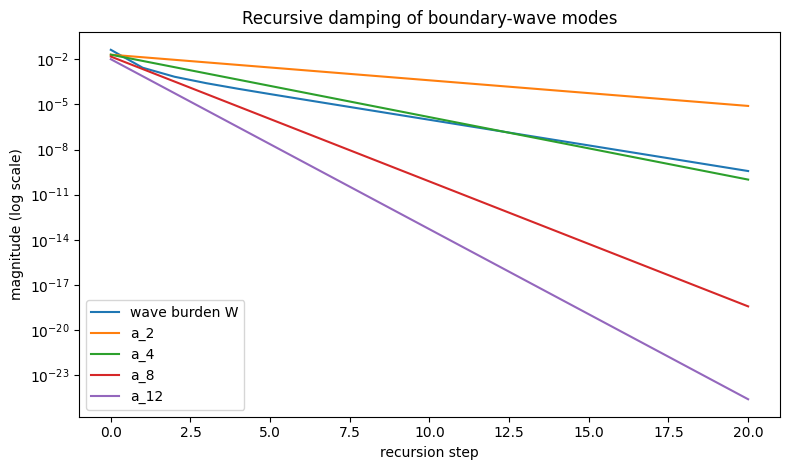

In [4]:

plt.figure(figsize=(8,4.8))
plt.semilogy(hist_df["step"], hist_df["W"], label="wave burden W")
for col in [c for c in hist_df.columns if c.startswith("a_")]:
    plt.semilogy(hist_df["step"], np.abs(hist_df[col]), label=col)
plt.xlabel("recursion step")
plt.ylabel("magnitude (log scale)")
plt.title("Recursive damping of boundary-wave modes")
plt.legend()
plt.tight_layout()
plt.show()


This is the first direct wave/recursion result in the gravity branch:

$$
\boxed{
\text{recursion naturally damps boundary roughness and drives } W \to 0.
}
$$

So under this model, the implementation coefficient relaxes to the base compactness-derived value:

$$
q_\Gamma^{(n)}
=
q_{\Gamma,0}\bigl(1+\nu W^{(n)}\bigr)
\longrightarrow
q_{\Gamma,0}.
$$

That is a clean geometric version of “the system rings itself into the stable pattern.” fileciteturn38file2turn38file11


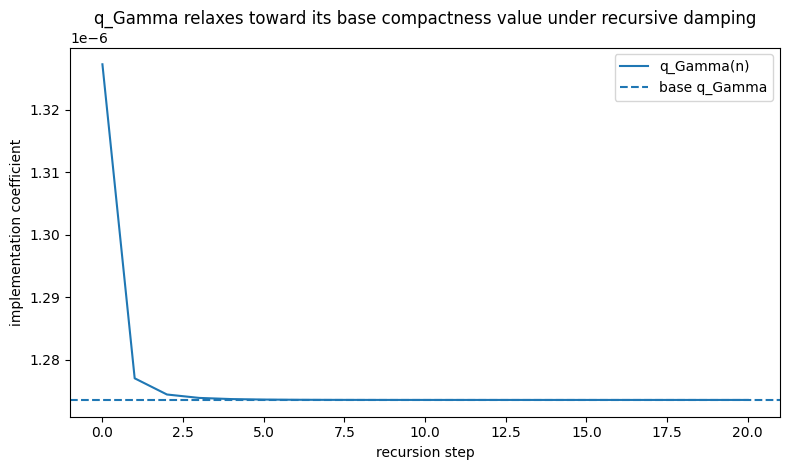

In [5]:

# Track q_Gamma during recursion for a Sun-like source
q_steps = []
q0 = base_q_gamma(M_sun, R_sun, chi=1.0, alpha_s=0.6)
nu = 1.0
for _, row in hist_df.iterrows():
    q_steps.append(q0 * (1 + nu * row["W"]))

plt.figure(figsize=(8,4.8))
plt.plot(hist_df["step"], q_steps, label="q_Gamma(n)")
plt.axhline(q0, linestyle="--", label="base q_Gamma")
plt.xlabel("recursion step")
plt.ylabel("implementation coefficient")
plt.title("q_Gamma relaxes toward its base compactness value under recursive damping")
plt.legend()
plt.tight_layout()
plt.show()


## 4. Observable effect of wave burden

Feed the wave-corrected coefficient into the same metric branch:

$$
\beta_\Gamma = 1+\xi q_\Gamma,
\qquad
\gamma_\Gamma = 1+\zeta q_\Gamma.
$$

Then the leading observable factors remain

$$
F_{\mathrm{peri}}
=
1+\frac{(2\zeta-\xi)}{3}q_\Gamma,
$$

$$
F_{\mathrm{bend}}
=
1+\frac{\zeta}{2}q_\Gamma.
$$

So shape roughness does not change the branch structure.
It changes the **magnitude** through the wave burden.


In [6]:

xi = 0.2
zeta = 0.4

def observable_factors_from_q(q, xi=0.2, zeta=0.4):
    F_peri = 1 + ((2*zeta - xi)/3) * q
    F_bend = 1 + (zeta/2) * q
    return F_peri, F_bend

rows = []
for name, modes in examples.items():
    q, q0, W = q_gamma_with_waves(M_sun, R_sun, modes, chi=1.0, alpha_s=0.6, nu=1.0)
    Fp, Fb = observable_factors_from_q(q, xi=xi, zeta=zeta)
    Fp0, Fb0 = observable_factors_from_q(q0, xi=xi, zeta=zeta)
    rows.append({
        "shape_packet": name,
        "W": W,
        "peri_factor": Fp,
        "bend_factor": Fb,
        "extra_peri_from_waves": Fp - Fp0,
        "extra_bend_from_waves": Fb - Fb0,
    })

obs_wave_df = pd.DataFrame(rows)
obs_wave_df


,shape_packet,W,peri_factor,bend_factor,extra_peri_from_waves,extra_bend_from_waves
0,smooth_ell2,0.0024,1.0,1.0,6.112992e-10,6.112992e-10
1,mixed_low_modes,0.0071,1.0,1.0,1.808427e-09,1.808427e-09
2,rougher_high_modes,0.0422,1.0,1.0,1.074868e-08,1.074868e-08


For ordinary solar compactness these wave-induced changes remain tiny, which is exactly what they should do.

But the logic is now present:

$$
\boxed{
\text{shape} \to \text{wave burden} \to q_\Gamma \to \text{metric observables.}
}
$$

So the branch now has a first direct path from shape to gravity-like output.


## 5. Compact-source amplification of shape burden

The real importance of the wave burden is not at solar compactness.
It is in compact sources.

Since

$$
q_{\Gamma,0} \propto \frac{GM}{Rc^2},
$$

the same relative wave burden $W$ produces a much larger absolute effect in neutron-star-like sources than in Sun-like sources.


In [7]:

# Compare Sun-like vs neutron-star-like source with same wave packet
M_ns = 1.4 * M_sun
R_ns = 1.2e4

compare_rows = []
for source_name, M, R in [("Sun-like", M_sun, R_sun), ("NS-like", M_ns, R_ns)]:
    q, q0, W = q_gamma_with_waves(M, R, examples["rougher_high_modes"], chi=1.0, alpha_s=0.6, nu=1.0)
    Fp, Fb = observable_factors_from_q(q, xi=xi, zeta=zeta)
    Fp0, Fb0 = observable_factors_from_q(q0, xi=xi, zeta=zeta)
    compare_rows.append({
        "source": source_name,
        "base_qGamma": q0,
        "wave_burden_W": W,
        "qGamma_total": q,
        "extra_peri_from_waves": Fp - Fp0,
        "extra_bend_from_waves": Fb - Fb0,
    })

compare_df = pd.DataFrame(compare_rows)
compare_df


,source,base_qGamma,wave_burden_W,qGamma_total,extra_peri_from_waves,extra_bend_from_waves
0,Sun-like,0.000001,0.0422,0.000001,1.074868e-08,1.074868e-08
1,NS-like,0.103367,0.0422,0.107729,8.724165e-04,8.724165e-04


This is the practical point.

The same shape packet is almost invisible in a Sun-like source but much larger in a neutron-star-like source.

So the branch now says:

$$
\boxed{
\text{boundary waves matter most when the source is already compact.}
}
$$

That is the exact regime logic we have been moving toward for several notebooks.


## 6. What this notebook actually proves

This notebook does **not** derive the full reflection kernel from first principles.

It does prove something important:

1. shape can be represented as boundary-wave content,
2. boundary-wave roughness gives a clean correction to the maintenance coefficient,
3. recursion acts naturally as a damping law on those modes,
4. the implementation coefficient relaxes toward its compactness-derived base value,
5. and compact sources amplify the same wave burden much more strongly than weak sources.

That is the first direct bridge between shape, recursion, waves, and the gravity branch.


## 7. Best current theorem candidate

The cleanest current extension of the sourced metric branch is now:

$$
\boxed{
q_\Gamma
=
\chi \alpha_s \frac{GM}{Rc^2}\bigl(1+\nu W\bigr),
\qquad
W=\sum_{\ell\ge 2}\ell(\ell+1)a_\ell^2.
}
$$

with recursive damping

$$
\boxed{
a_\ell^{(n+1)}=
\frac{a_\ell^{(n)}}{1+\kappa \ell(\ell+1)}.
}
$$

Then

$$
\boxed{
(\mathcal B,\mathcal T,\mathcal R)
\to
\text{boundary waves}
\to
W
\to
q_\Gamma
\to
(\beta_\Gamma,\gamma_\Gamma)
\to
\text{effective metric}
\to
\text{precession, lensing, clock shift}.
}
$$

In plain language:

$$
\boxed{
\text{gravity is the first metric implementation of runtime persistence, and boundary shape enters through wave burden that recursion damps toward the stable attractor.}
}
$$


## 8. Next exact move

The next continuation is now very sharp:

derive the wave burden

$$
W
$$

from the actual reflection kernel rather than choosing its Laplacian form by symmetry and plausibility alone.

That is the next real boundary.
